# CartPole Q-Learning 실습 (PyTorch)

CartPole 환경에서 Q-Learning을 사용하여 막대기 균형 잡기를 학습합니다.

## 환경설정

In [1]:
# 필요한 라이브러리 설치
!pip install gymnasium[classic-control] -q
!pip install pygame -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from IPython import display
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
plt.style.use('default')
sns.set_palette("husl")

# PyTorch 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. CartPole 환경 이해하기

In [2]:
# 환경 생성
env = gym.make('CartPole-v1')

print("=" * 60)
print("CartPole-v1 환경 정보")
print("=" * 60)
print(f"State 공간: {env.observation_space}")
print(f"Action 공간: {env.action_space}")
print(f"\nState 구성 요소:")
print("  - Cart Position: 카트의 위치 (범위: -4.8 ~ 4.8)")
print("  - Cart Velocity: 카트의 속도")
print("  - Pole Angle: 막대기의 각도 (범위: -0.418 ~ 0.418 rad, 약 -24 ~ 24도)")
print("  - Pole Angular Velocity: 막대기의 각속도")
print(f"\nAction:")
print("  - 0: 왼쪽으로 밀기")
print("  - 1: 오른쪽으로 밀기")
print(f"\n목표: 막대기를 최대한 오래 세워두기 (최대 500 스텝)")

CartPole-v1 환경 정보
State 공간: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action 공간: Discrete(2)

State 구성 요소:
  - Cart Position: 카트의 위치 (범위: -4.8 ~ 4.8)
  - Cart Velocity: 카트의 속도
  - Pole Angle: 막대기의 각도 (범위: -0.418 ~ 0.418 rad, 약 -24 ~ 24도)
  - Pole Angular Velocity: 막대기의 각속도

Action:
  - 0: 왼쪽으로 밀기
  - 1: 오른쪽으로 밀기

목표: 막대기를 최대한 오래 세워두기 (최대 500 스텝)


## 2. State Discretization (이산화)

연속적인 state 공간을 이산화하여 Q-Table을 만듭니다.

In [3]:
class StateDiscretizer:
    """연속 state를 이산 state로 변환하는 클래스"""

    def __init__(self, num_bins=[10, 10, 10, 10]):
        """
        Args:
            num_bins: 각 state 차원별 bin 개수
        """
        self.num_bins = num_bins

        # 각 차원의 범위 설정 (CartPole 기준)
        self.state_bounds = [
            [-4.8, 4.8],      # Cart Position
            [-4.0, 4.0],      # Cart Velocity
            [-0.418, 0.418],  # Pole Angle (약 -24 ~ 24도)
            [-4.0, 4.0]       # Pole Angular Velocity
        ]

    def discretize(self, state):
        """연속 state를 이산 인덱스로 변환"""
        discrete_state = []

        for i, value in enumerate(state):
            # 값을 범위 내로 클리핑
            value = np.clip(value, self.state_bounds[i][0], self.state_bounds[i][1])

            # bin 인덱스 계산
            scaling = (value - self.state_bounds[i][0]) / (self.state_bounds[i][1] - self.state_bounds[i][0])
            bin_idx = int(scaling * (self.num_bins[i] - 1))
            bin_idx = np.clip(bin_idx, 0, self.num_bins[i] - 1)

            discrete_state.append(bin_idx)

        return tuple(discrete_state)

# Discretizer 생성
discretizer = StateDiscretizer(num_bins=[6, 6, 12, 12])
print("\n" + "=" * 60)
print("State Discretization 설정")
print("=" * 60)
print(f"총 가능한 state 수: {6 * 6 * 12 * 12:,}")


State Discretization 설정
총 가능한 state 수: 5,184


## 3. Q-Learning Agent 구현

In [4]:
class QLearningAgent:
    """Q-Learning 에이전트"""

    def __init__(self, state_shape, n_actions, learning_rate=0.1,
                 discount_factor=0.99, epsilon=1.0, epsilon_decay=0.995,
                 epsilon_min=0.01):
        """
        Args:
            state_shape: 이산화된 state의 shape
            n_actions: action 개수
            learning_rate: 학습률 (alpha)
            discount_factor: 할인율 (gamma)
            epsilon: 초기 탐험률
            epsilon_decay: epsilon 감소율
            epsilon_min: 최소 epsilon 값
        """
        self.state_shape = state_shape
        self.n_actions = n_actions
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Q-Table 초기화 (모든 값을 0으로)
        self.q_table = np.zeros(state_shape + (n_actions,))

    def get_action(self, state, training=True):
        """Epsilon-greedy 정책으로 action 선택"""
        if training and np.random.random() < self.epsilon:
            # 탐험: 랜덤 action
            return np.random.randint(self.n_actions)
        else:
            # 활용: 최대 Q값을 가진 action
            return np.argmax(self.q_table[state])

    def update(self, state, action, reward, next_state, done):
        """Q-Table 업데이트"""
        # 현재 Q값
        current_q = self.q_table[state][action]

        if done:
            # 에피소드가 끝났으면 next_state의 Q값은 0
            target_q = reward
        else:
            # Q-Learning 업데이트 식
            max_next_q = np.max(self.q_table[next_state])
            target_q = reward + self.gamma * max_next_q

        # Q값 업데이트
        self.q_table[state][action] = current_q + self.lr * (target_q - current_q)

    def decay_epsilon(self):
        """Epsilon 감소"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# Agent 생성
state_shape = (6, 6, 12, 12)  # discretizer의 num_bins
n_actions = env.action_space.n

agent = QLearningAgent(
    state_shape=state_shape,
    n_actions=n_actions,
    learning_rate=0.1,
    discount_factor=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01
)

print("\n" + "=" * 60)
print("Q-Learning Agent 생성 완료")
print("=" * 60)
print(f"Q-Table 크기: {agent.q_table.shape}")
print(f"총 Q-값 개수: {agent.q_table.size:,}")


Q-Learning Agent 생성 완료
Q-Table 크기: (6, 6, 12, 12, 2)
총 Q-값 개수: 10,368


## 4. 학습 진행

In [5]:
def train_agent(agent, env, discretizer, num_episodes=1000, max_steps=500):
    """에이전트 학습"""

    episode_rewards = []
    episode_lengths = []
    epsilon_history = []
    recent_rewards = deque(maxlen=100)  # 최근 100개 에피소드의 평균 계산용

    print("\n" + "=" * 60)
    print("학습 시작")
    print("=" * 60)

    for episode in range(num_episodes):
        state, _ = env.reset()
        state = discretizer.discretize(state)

        total_reward = 0

        for step in range(max_steps):
            # Action 선택
            action = agent.get_action(state, training=True)

            # 환경에서 한 스텝 진행
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretizer.discretize(next_state)

            # Q-Table 업데이트
            agent.update(state, action, reward, next_state, done)

            total_reward += reward
            state = next_state

            if done:
                break

        # Epsilon 감소
        agent.decay_epsilon()

        # 통계 기록
        episode_rewards.append(total_reward)
        episode_lengths.append(step + 1)
        epsilon_history.append(agent.epsilon)
        recent_rewards.append(total_reward)

        # 진행상황 출력
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(recent_rewards)
            print(f"Episode {episode + 1}/{num_episodes} | "
                  f"Avg Reward (last 100): {avg_reward:.2f} | "
                  f"Epsilon: {agent.epsilon:.4f}")

    print("\n학습 완료!")

    return episode_rewards, episode_lengths, epsilon_history

# 학습 실행
num_episodes = 1000
episode_rewards, episode_lengths, epsilon_history = train_agent(
    agent, env, discretizer, num_episodes=num_episodes
)


학습 시작
Episode 100/1000 | Avg Reward (last 100): 30.48 | Epsilon: 0.6058
Episode 200/1000 | Avg Reward (last 100): 39.36 | Epsilon: 0.3670
Episode 300/1000 | Avg Reward (last 100): 80.87 | Epsilon: 0.2223
Episode 400/1000 | Avg Reward (last 100): 96.48 | Epsilon: 0.1347
Episode 500/1000 | Avg Reward (last 100): 118.36 | Epsilon: 0.0816
Episode 600/1000 | Avg Reward (last 100): 118.97 | Epsilon: 0.0494
Episode 700/1000 | Avg Reward (last 100): 112.88 | Epsilon: 0.0299
Episode 800/1000 | Avg Reward (last 100): 121.65 | Epsilon: 0.0181
Episode 900/1000 | Avg Reward (last 100): 123.42 | Epsilon: 0.0110
Episode 1000/1000 | Avg Reward (last 100): 113.88 | Epsilon: 0.0100

학습 완료!


## 5. 학습 결과 시각화

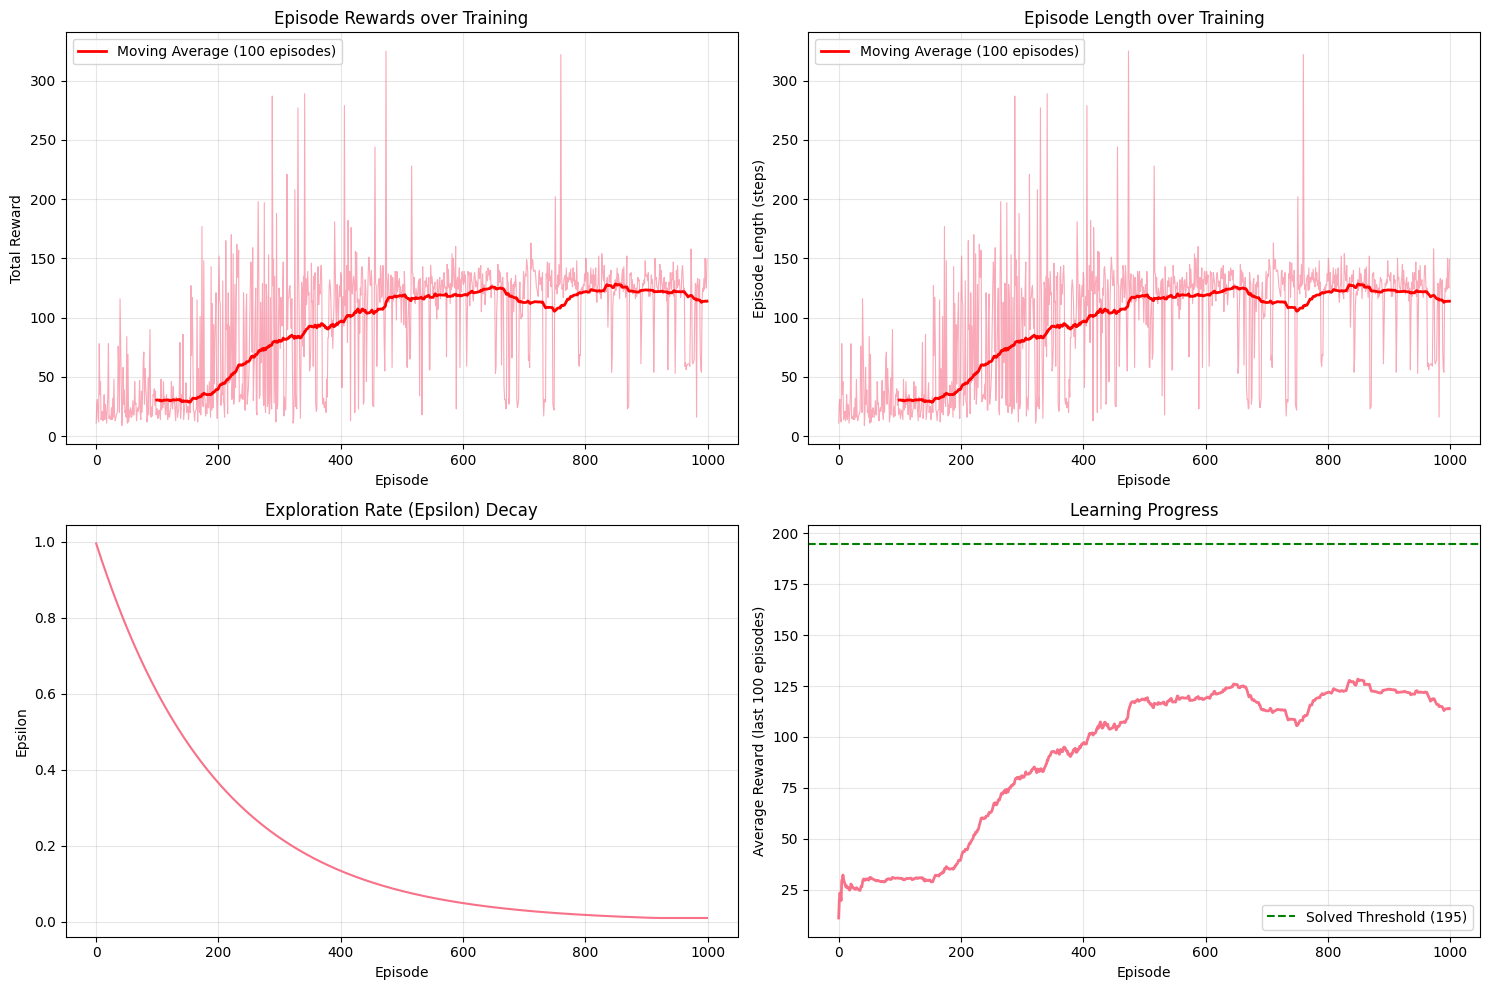


학습 통계
총 에피소드 수: 1000
최고 보상: 325.00
최근 100 에피소드 평균 보상: 113.88
최종 Epsilon: 0.0100

계속 학습하면 더 좋은 성능을 얻을 수 있습니다!


In [7]:
# 5.1 학습 곡선
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Episode Rewards
axes[0, 0].plot(episode_rewards, alpha=0.6, linewidth=0.8)
# 이동 평균 (100 에피소드)
moving_avg = np.convolve(episode_rewards, np.ones(100)/100, mode='valid')
axes[0, 0].plot(range(99, len(episode_rewards)), moving_avg, 'r-', linewidth=2, label='Moving Average (100 episodes)')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].set_title('Episode Rewards over Training')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Episode Lengths
axes[0, 1].plot(episode_lengths, alpha=0.6, linewidth=0.8)
moving_avg_len = np.convolve(episode_lengths, np.ones(100)/100, mode='valid')
axes[0, 1].plot(range(99, len(episode_lengths)), moving_avg_len, 'r-', linewidth=2, label='Moving Average (100 episodes)')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Episode Length (steps)')
axes[0, 1].set_title('Episode Length over Training')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Epsilon Decay
axes[1, 0].plot(epsilon_history)
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Epsilon')
axes[1, 0].set_title('Exploration Rate (Epsilon) Decay')
axes[1, 0].grid(True, alpha=0.3)

# 최근 100 에피소드의 평균 보상
recent_avg = [np.mean(episode_rewards[max(0, i-99):i+1]) for i in range(len(episode_rewards))]
axes[1, 1].plot(recent_avg, linewidth=2)
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Average Reward (last 100 episodes)')
axes[1, 1].set_title('Learning Progress')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=195, color='g', linestyle='--', label='Solved Threshold (195)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 5.2 학습 통계
print("\n" + "=" * 60)
print("학습 통계")
print("=" * 60)
print(f"총 에피소드 수: {num_episodes}")
print(f"최고 보상: {max(episode_rewards):.2f}")
print(f"최근 100 에피소드 평균 보상: {np.mean(episode_rewards[-100:]):.2f}")
print(f"최종 Epsilon: {agent.epsilon:.4f}")

# CartPole-v1은 평균 195점 이상이면 "solved"로 간주
if np.mean(episode_rewards[-100:]) >= 195:
    print("\n🎉 환경 해결! (Solved: 195+ average reward)")
else:
    print("\n계속 학습하면 더 좋은 성능을 얻을 수 있습니다!")

## 6. 학습된 에이전트 테스트

In [8]:
def test_agent(agent, env, discretizer, num_episodes=10, render=False):
    """학습된 에이전트 테스트"""

    test_rewards = []
    test_lengths = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        state = discretizer.discretize(state)

        total_reward = 0
        steps = 0

        while True:
            # 학습된 정책으로 action 선택 (탐험 없음)
            action = agent.get_action(state, training=False)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretizer.discretize(next_state)

            total_reward += reward
            steps += 1
            state = next_state

            if done:
                break

        test_rewards.append(total_reward)
        test_lengths.append(steps)
        print(f"Test Episode {episode + 1}: Reward = {total_reward:.2f}, Length = {steps}")

    return test_rewards, test_lengths

print("\n" + "=" * 60)
print("학습된 에이전트 테스트")
print("=" * 60)

test_rewards, test_lengths = test_agent(agent, env, discretizer, num_episodes=10)

print("\n" + "=" * 60)
print("테스트 결과")
print("=" * 60)
print(f"평균 보상: {np.mean(test_rewards):.2f} ± {np.std(test_rewards):.2f}")
print(f"평균 길이: {np.mean(test_lengths):.2f} ± {np.std(test_lengths):.2f}")
print(f"최고 보상: {max(test_rewards):.2f}")
print(f"최저 보상: {min(test_rewards):.2f}")


학습된 에이전트 테스트
Test Episode 1: Reward = 129.00, Length = 129
Test Episode 2: Reward = 128.00, Length = 128
Test Episode 3: Reward = 115.00, Length = 115
Test Episode 4: Reward = 127.00, Length = 127
Test Episode 5: Reward = 129.00, Length = 129
Test Episode 6: Reward = 119.00, Length = 119
Test Episode 7: Reward = 128.00, Length = 128
Test Episode 8: Reward = 117.00, Length = 117
Test Episode 9: Reward = 117.00, Length = 117
Test Episode 10: Reward = 128.00, Length = 128

테스트 결과
평균 보상: 123.70 ± 5.57
평균 길이: 123.70 ± 5.57
최고 보상: 129.00
최저 보상: 115.00


## 7. 실제 플레이 시각화

In [12]:
from matplotlib import animation
from IPython.display import HTML

def visualize_best_episode(agent, env, discretizer, num_trials=10):
    """여러 번 실행해서 가장 좋은 에피소드를 시각화"""

    print(f"\n{'='*60}")
    print(f"최고 성능 에피소드 찾는 중... ({num_trials}번 시도)")
    print(f"{'='*60}\n")

    best_frames = None
    best_reward = -1
    best_steps = 0

    # 여러 번 실행해서 가장 좋은 것 찾기
    for trial in range(num_trials):
        env_render = gym.make('CartPole-v1', render_mode='rgb_array')
        state, _ = env_render.reset()
        state = discretizer.discretize(state)

        frames = []
        total_reward = 0
        step = 0

        while True:
            frame = env_render.render()
            frames.append(frame)

            action = agent.get_action(state, training=False)
            next_state, reward, terminated, truncated, _ = env_render.step(action)
            done = terminated or truncated
            next_state = discretizer.discretize(next_state)

            total_reward += reward
            step += 1
            state = next_state

            if done:
                break

        env_render.close()

        print(f"Trial {trial + 1}/{num_trials}: Reward = {total_reward:.2f}, Steps = {step}")

        # 최고 기록 갱신
        if total_reward > best_reward:
            best_reward = total_reward
            best_steps = step
            best_frames = frames.copy()
            # 마지막 프레임 반복
            for _ in range(15):
                best_frames.append(frames[-1])

    print(f"\n{'='*60}")
    print(f"최고 성능 에피소드 선택!")
    print(f"Best Reward: {best_reward:.2f}, Best Steps: {best_steps}")
    print(f"{'='*60}\n")

    # 최고 에피소드 애니메이션 생성 및 표시
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axis('off')
    img = ax.imshow(best_frames[0])

    def animate(frame_idx):
        img.set_array(best_frames[frame_idx])
        if frame_idx < best_steps:
            ax.set_title(f'Step: {frame_idx + 1}/{best_steps} | Best Episode (Reward: {best_reward:.0f})',
                        fontsize=14, fontweight='bold')
        else:
            ax.set_title(f'Episode Finished! | Total Steps: {best_steps} | Total Reward: {best_reward:.0f}',
                        fontsize=14, fontweight='bold', color='green')
        return [img]

    anim = animation.FuncAnimation(fig, animate, frames=len(best_frames),
                                  interval=50, blit=True, repeat=True)

    plt.close()  # 중복 표시 방지
    return HTML(anim.to_jshtml())  # HTML로 변환하여 반환

# 학습된 에이전트의 최고 플레이 시각화
print("\n" + "=" * 60)
print("학습된 에이전트 최고 플레이 시각화")
print("=" * 60)

visualize_best_episode(agent, env, discretizer, num_trials=10)

Output hidden; open in https://colab.research.google.com to view.

## 8. Q-Table 분석

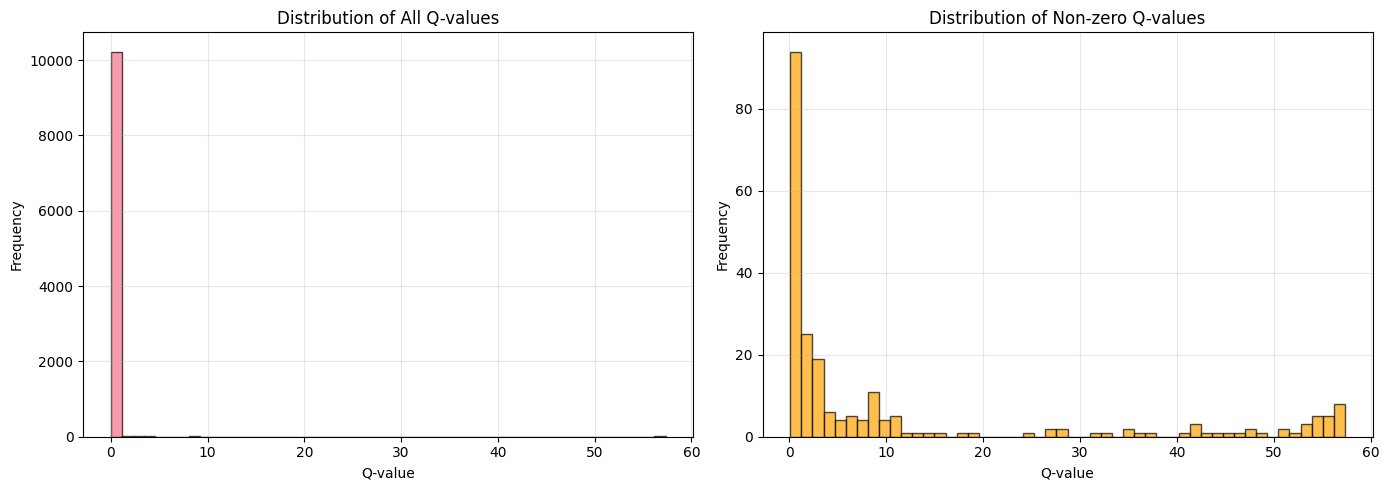


Q-Table 분석
총 Q-값 개수: 10,368
0이 아닌 Q-값 개수: 229 (2.21%)
최대 Q-값: 57.3235
최소 Q-값: 0.0000
평균 Q-값 (non-zero): 11.7263

실습 완료!

주요 학습 내용:
1. Q-Learning 알고리즘의 기본 원리
2. 연속 state 공간을 이산화하는 방법
3. Epsilon-greedy 탐험 전략
4. Q-Table 업데이트 과정
5. 학습 과정 시각화 및 분석

다음 단계: Deep Q-Network (DQN)으로 더 복잡한 환경 도전!


In [10]:
# 8.1 Q-값 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 모든 Q-값의 분포
q_values = agent.q_table.flatten()
axes[0].hist(q_values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Q-value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of All Q-values')
axes[0].grid(True, alpha=0.3)

# 0이 아닌 Q-값만 (실제로 방문한 state-action 쌍)
non_zero_q = q_values[q_values != 0]
axes[1].hist(non_zero_q, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Q-value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Non-zero Q-values')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8.2 Q-Table 통계
print("\n" + "=" * 60)
print("Q-Table 분석")
print("=" * 60)
print(f"총 Q-값 개수: {agent.q_table.size:,}")
print(f"0이 아닌 Q-값 개수: {np.count_nonzero(agent.q_table):,} ({100*np.count_nonzero(agent.q_table)/agent.q_table.size:.2f}%)")
print(f"최대 Q-값: {np.max(agent.q_table):.4f}")
print(f"최소 Q-값: {np.min(agent.q_table):.4f}")
print(f"평균 Q-값 (non-zero): {np.mean(non_zero_q):.4f}")

# 환경 종료
env.close()

